## KELT-20b Evolution

This notebook details the analytical model built by Annelise Alvin, in collaboration with Dr. Melinda Soares-Furtado and Dr. Juliette Becker, to explore whether equilibrium tides alone could explain the current orbital architecture of the KELT-20 planetary system. KELT-20 is a young, A-type star with a closely orbiting gas giant companion&mdash;the hot Jupiter KELT-20b. The planet's orbit has a semi-major axis of 0.0542 Astronomical Units (AU) and an eccentricity of 0. The KELT-20 system has an age constraint of 110 Myr, which may not have been enough time for the planet to migrate inward due to equilibrium tides. In this notebook, we explored the equilibrium tide model and found that the planet could **not** have migrated inward within the age of the system, indicating that another mechanism must be needed to explain this orbital architecture.

The equations used in the **Analytical Model** section are found in Hut (1981). The formatting and content of this notebook is greatly inspired by two REBOUNDx example notebooks: [TidesConstantTimeLag.ipynb](https://github.com/dtamayo/reboundx/blob/main/ipython_examples/TidesConstantTimeLag.ipynb) and [TidesSpinPseudoSynchronization.ipynb](https://github.com/dtamayo/reboundx/blob/main/ipython_examples/TidesSpinPseudoSynchronization.ipynb).

### Parameters

We used values from Lund (2017) for the stellar and planetary masses and radii and the stellar luminosity. The stellar Love number and the radius of gyration are found in Claret (2019) from astroseismic models. Vsin<em>i</em> comes from Rainer (2021). The parameters inputted into the model are in units of $M_\odot$, AU, and years for simplicity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
np.random.seed(42)

# Stellar parameters - KELT-20
stellar_mass = 1.76  # solar masses
stellar_radius = 1.565 * 0.00465  # AU (1.565 solar radii)
k2_s = 0.005  # stellar Love number
rg = 0.21  # radius of gyration

# Planetary parameters - KELT-20b
planetary_mass = 1 * 0.000954588  # solar masses (1 Jupiter mass)
planetary_radius = 1.741 * 0.000477895  # AU (1.741 Jupiter radii) 

G = 4*np.pi**2  # AU^3 / (yr^2 Msun)

#### Rotation Period

The rotation period of the star has great effects on the efficiency of tidal migration. As KELT-20 is an extremely young A-type star, it is expected to have a rapid rotation rate. To calculate the rotation period, we used the stellar radius and projected rotational velocity vsin<em>i</em>. According to Lund, the inclination of the star is constrained to 24&deg; < <em> i </em> < 156&deg;, so we calculated a maximum period (with 90&deg; inclination) and a minimum period (with 156&deg; inclination) to use when modeling the orbital evolution.

In [2]:
vsini = 116.25  # km/s
r_km = 1.565 * 695700  # stellar radius in kilometers

p_upper = 2 * np.pi * r_km * np.sin(90 * np.pi/180) / vsini / 86400  # days
p_lower = 2 * np.pi * r_km * np.sin(156 * np.pi/180) / vsini / 86400  # days
print(f"Minimum period: {p_lower:.2} days,", f"Maximum period: {p_upper:.2f} days")

# Setting stellar rotation to be used in the model
period = p_upper  # days
period = period * 0.00273973  # yearss
omega_0 = 2 * np.pi / period

Minimum period: 0.28 days, Maximum period: 0.68 days


The minimum period that is determined in the previous code, or 0.28 days, seems quite small. To check if this value is physically reasonable, we calculated the critical velocity, or the maximum rotational velocity the star can have before its gravity is unable to hold it together. We used this critical velocity to calculate the critical period. This calculation does not include a sin<em>i</em> term as it is a maximum possible velocity, which would occur for <em>i</em> = 90&deg;, sin(90&deg;) = 1.

We found that the critical period was around 0.17 days, which indicates that the minimum period we calculated previously is physically reasonable.

We also defined the stellar parameters again in centimeter-gram-second units to ensure accuracy, and for later use in calculating the convective friction time.

In [3]:
# Parameters in centimeter-gram-second units
G_cgs = 6.674e-8  # [dyn cm^2 / g^2]
m_cgs = 1.76 * 1.989e33  # stellar mass in grams
r_cgs = 1.565 * 6.955e10  # stellar radius in cm 
l_cgs = 12.7 * 4e33  # stellar luminosity in erg/s

# Critical velocity
critical_v_cgs = np.sqrt(G_cgs * m_cgs / r_cgs)  # cm/s
print(f"Critical velocity: {(critical_v_cgs / 100000):.5} km/s")

# Critical period
critical_p_days = 2 * np.pi * r_cgs / critical_v_cgs / 86400  # days
print(f"Critical period: {critical_p_days:.2} days")

Critical velocity: 463.3 km/s
Critical period: 0.17 days


#### Initial Orbital Geometry

In analyzing the KELT-20 system, it is important to consider how far away the planet could have formed before migrating. Gas giants typically form beyond the snow line, or the distance from the star at which the temperature is low enough for volatiles (water, carbon dioxide, etc.) to be in their solid state. **tbd - citation**

The snow line of a bright star scales as $r=2.7 *(L_\star/L_\odot)^{1/2}$. Another relation is $r=2.7 *(M_\star/M_\odot)^2$. We find a snow line of 8.4&ndash;9.6 AU, depending on the relation, which is much further out than that of the Sun. This indicates that we should explore initial semi-major axis ($a$) values beyond the snow line. We explore initial $a$ values from 7&ndash;20 AU.

We calculate the eccentricity ($e$) of the initial orbit using a simple relation with the semi-major axis. The current orbit of the star has $a = 0.0542$ and $e = 0$. A planet with a highly eccentric orbit will circularize to a radius of twice its initial periastron distance ($q)$, or distance of closest approach. **tbd - citation** This indicates that the planet must have begun with an initial distance of &asymp;0.025 AU at periastron. With a known periastron distance and semi-major axis, calculating the necessary eccentricity can be easily done with $e = 1-q/a$.

In [4]:
# Final orbital conditions
a_final = 0.0542
e_final = 0
star_age = 1.1e8

# Snow line
rsnow=2.7 *np.sqrt(12.7)  # 12.7 = Lstar/Lsun
print(f"Snow line 1: {rsnow:.2} AU")

rsnow=2.7 *(1.76)**2  # 1.76 = Mstar/Msun
print(f"Snow line 2: {rsnow:.2} AU")

# Setting initial orbital geometry
a_array = np.linspace(7, 20, 20)
e_array = 1 - 0.025 / a_array

Snow line 1: 9.6 AU
Snow line 2: 8.4 AU


#### Constant Time Lag Parameter

We modeled equilibrium tides with the constant time lag model described in Hut (1981). We used the definitions of convective friction time and constant time lag as outlined in the REBOUNDx example notebook [TidesConstantTimeLag.ipynb](https://github.com/dtamayo/reboundx/blob/main/ipython_examples/TidesConstantTimeLag.ipynb), which draws from Zahn (1981) and Baronett et al. (2022). The constant time lag parameter ($\tau$) describes how much energy is dissipated in the envelope of the star. $\tau$ is defined as
$$
\tau = \frac{2R^3}{GMt_f}
$$
where $R$ and $M$ are the stellar mass and radius, $G$ is the gravitational constant, and $t_f$ is the convective friction time, 
$$
t_f = (\frac{MR^2}{L})^{1/3},
$$
where $L$ is the stellar luminosity. These parameters are calculated below in units of years.

In [5]:
# Convective friction time
t_f_s = (m_cgs * r_cgs **2 / l_cgs)**(1/3)  # seconds
t_f = t_f_s / 31556952  # years
print(f"Convective friction time: {t_f:.2} years")

# Tidal time lag
tau = 2 * stellar_radius**3 / (G * stellar_mass * t_f)
print(f"Constant time lag: {tau:.2} years")

Convective friction time: 0.3 years
Constant time lag: 3.7e-08 years


### Hut Model

We used the differential equations defined in Hut (1981) to model the evolution of the semi-major axis and eccentricity of the planet's orbit as well as the rotation rate of the star. We added a condition to effectively stop recording change when the semi-major axis decreased to below the radius of the star to prevent recording nonphysical results. The hut_model function is defined similarly to the model in the [TidesSpinPseudoSynchronization.ipynb](https://github.com/dtamayo/reboundx/blob/main/ipython_examples/TidesSpinPseudoSynchronization.ipynb) REBOUNDx example notebook. 

In [6]:
def f1_hut(e2):
    return 1 + (31/2)*e2 + (255/8)*e2**2 + (185/16)*e2**3 + (25/64)*e2**4

def f2_hut(e2):
    return 1 + (15/2)*e2 + (45/8)*e2**2 + (5/16)*e2**3

def f3_hut(e2):
    return 1 + (15/4)*e2 + (15/8)*e2**2 + (5/64)*e2**3

def f4_hut(e2):
    return 1 + (3/2)*e2 + (1/8)*e2**2

def f5_hut(e2):
    return 1 + 3*e2 + (3/8)*e2**2


def hut_model(params, t, mstar, rstar, k2star, mplanet, tau, rg):
    a, e, omega = params
    
    if a < rstar:
        return [0,0,0]
    
    k =  k2star
    
    n = np.sqrt(G*(mstar + mplanet)/a**3)

    T = rstar**3 / (G * mstar *  tau) 

    q = mplanet / mstar

    rg = rg
    
    da_dt = -6 * (k / T) * q * (1 + q) * (rstar / a)**8 * a * (1 - e**2)**(-15/2) * (
         f1_hut(e**2) - (1 - e**2)**(3/2) * f2_hut(e**2) * omega / n)

    de_dt = -27 * (k / T) * q * (1 + q) * (rstar / a)**8 * e * (1 - e**2)**(-13/2) * (
        f3_hut(e**2) - 11/18 * (1 - e**2)**(3/2) * f4_hut(e**2) * omega / n)

    domega_dt = 3 * (k / T) * (q / rg)**2 * (rstar / a)**6 * n * (1-e**2)**(-6) * (
        f2_hut(e**2) - (1 - e**2)**(3/2) * f5_hut(e**2) * omega / n)

    
    return [da_dt, de_dt, domega_dt]


### Running Model and Plotting

We define a time array to best show the result of the plot. We evaluate the analytical model for each initial semi-major axis and eccentricity pair using the scipy odeint differential equation integrator, then plot the evolution of the semi-major axis, eccentricity, and angular frequency versus time. These plots show that for our best estimate of realistic stellar rotation period and planetary mass, we see an inward migration. This is due to the low estimated rotation period of the star. The relationship between this low period and the orbital period of the planet causes a transfer of angular momentum from the star to the planet*, causing the planet to migrate outward and the star to spin down.

For a rotation period around 0.8 days, we see the planet migrate inward. However, the migration does not happen quickly enough to show the planet circularizing within the necessary 110 Myr constraint. Additionally, our upper limit for a rotation period is lower than 0.8 days, so any higher value that would cause inward migration is not physically reasonable according to our calculations and modeling of the rapid rotation of young A-type stars.

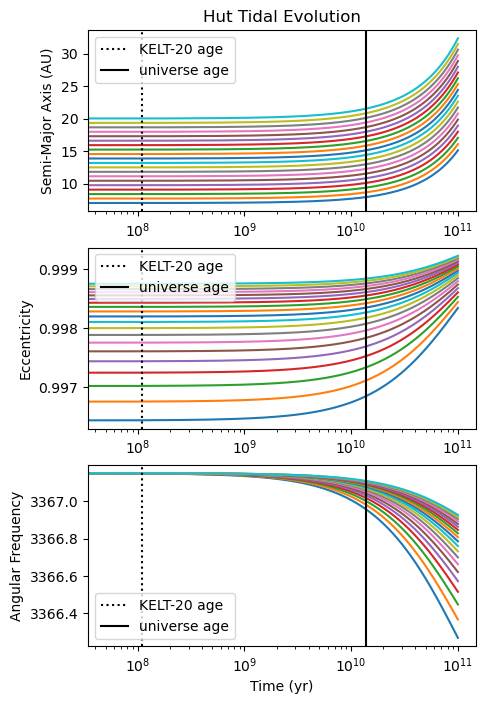

In [7]:
# Time
tmax = 1e11
Nout = 2000
hut_times = np.linspace(0, tmax, Nout)

# Setting up plot
fig, ax = plt.subplots(3, 1, figsize = (5,8))

for i in range(len(a_array)):
    a0 = a_array[i]
    e0 = e_array[i]
    
    initial_cond = [a0, e0, omega_0] 
    
    hut_solution = odeint(hut_model, initial_cond, hut_times, 
                               args = (stellar_mass, stellar_radius, k2_s, 
                                      planetary_mass, tau, rg))

    a_sol = hut_solution[:, 0]
    e_sol = hut_solution[:, 1]
    o_sol = hut_solution[:, 2]
    
    ax[0].plot(hut_times, a_sol)
    ax[1].plot(hut_times, e_sol)
    ax[2].plot(hut_times, o_sol)

ax[0].set_title("Hut Tidal Evolution")
ax[0].set_ylabel("Semi-Major Axis (AU)")
ax[0].set_xscale("log")
ax[0].axvline(x = 110e6, color = "k", linestyle = "dotted", label = "KELT-20 age")
ax[0].axvline(x = 1.38e10, color = "k", label = "universe age")

ax[1].set_ylabel("Eccentricity")
ax[1].set_xscale("log")
ax[1].axvline(x = 110e6, color = "k", linestyle = "dotted", label = "KELT-20 age")
ax[1].axvline(x = 1.38e10, color = "k", label = "universe age")

ax[2].set_ylabel("Angular Frequency")
ax[2].set_xlabel("Time (yr)")
ax[2].set_xscale("log")
ax[2].axvline(x = 110e6, color = "k", linestyle = "dotted", label = "KELT-20 age")
ax[2].axvline(x = 1.38e10, color = "k", label = "universe age")

ax[0].legend(loc = "upper left")
ax[1].legend(loc = "upper left")
ax[2].legend(loc = "lower left")

# plt.savefig("a_e_evolution_no_circ")

## Discussion

We conclude that the current orbital architecture of the KELT-20 planetary system cannot be explained by the equilibrium tide model alone. This indicates that other factors must be present to have caused the rapid inward migration of the hot Jupiter KELT-20b. Future work could explore the disk migration mechanism or the addition of dynamical tides to our equilibrium tide model.